# Brain Tumor Classification with Deep Learning & Grad-CAM
End-to-end medical vision pipeline for multi-class brain MRI classification. Includes EDA, custom CNN baseline, fine-tuned MobileNetV2, clinical evaluation, and Grad-CAM explainability.


## 1. Setup & Environment
Configure the Keras PyTorch backend to utilize the NVIDIA RTX 4060 GPU and enforce deterministic seeds.


In [1]:
import os
os.environ['KERAS_BACKEND'] = 'torch'

import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2

import torch
import keras
from keras import layers, models, optimizers, callbacks
from keras.applications import MobileNetV2
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, recall_score, f1_score
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf

# Enforce deterministic reproducibility
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
keras.utils.set_random_seed(SEED)

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

DATA_DIR = os.getcwd()
if not os.path.exists(os.path.join(DATA_DIR, 'Training')):
    DATA_DIR = r"C:\Users\Mahmoud\Downloads\Brain Tumor Classification"

print(f"Data Directory: {DATA_DIR}")
print(f"Keras Backend: {keras.config.backend()}")
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Device: {torch.cuda.get_device_name(0)}")


Data Directory: c:\Users\Mahmoud\Downloads\Brain Tumor Classification
Keras Backend: torch
PyTorch Version: 2.6.0+cu124
CUDA Available: True
GPU Device: NVIDIA GeForce RTX 4060 Laptop GPU


## 2. Dataset Loading & Indexing
Index all image paths and labels across training and testing folders into a single DataFrame.


In [2]:
classes = ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
base_splits = ['Training', 'Testing']

image_paths = []
labels = []
split_origins = []

for split in base_splits:
    split_path = os.path.join(DATA_DIR, split)
    if not os.path.exists(split_path):
        continue
    for cls in classes:
        cls_dir = os.path.join(split_path, cls)
        if os.path.isdir(cls_dir):
            for fname in os.listdir(cls_dir):
                if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                    image_paths.append(os.path.join(cls_dir, fname))
                    labels.append(cls)
                    split_origins.append(split)

df = pd.DataFrame({
    'filepath': image_paths,
    'label': labels,
    'split_origin': split_origins
})

label_to_idx = {name: i for i, name in enumerate(classes)}
idx_to_label = {i: name for i, name in enumerate(classes)}
df['label_idx'] = df['label'].map(label_to_idx)
print(label_to_idx)
print(f"Total Indexed Images: {len(df):,}")
df.head()


{'glioma_tumor': 0, 'meningioma_tumor': 1, 'no_tumor': 2, 'pituitary_tumor': 3}
Total Indexed Images: 3,264


,filepath,label,split_origin,label_idx
0,c:\Users\Mahmoud\Downloads\Brain Tumor Classif...,glioma_tumor,Training,0
1,c:\Users\Mahmoud\Downloads\Brain Tumor Classif...,glioma_tumor,Training,0
2,c:\Users\Mahmoud\Downloads\Brain Tumor Classif...,glioma_tumor,Training,0
3,c:\Users\Mahmoud\Downloads\Brain Tumor Classif...,glioma_tumor,Training,0
4,c:\Users\Mahmoud\Downloads\Brain Tumor Classif...,glioma_tumor,Training,0


## 3. Exploratory Data Analysis (EDA)
Analyze class distribution, inspect potential imbalance, and compute balanced class weights.


Class Counts:
label
meningioma_tumor    937
glioma_tumor        926
pituitary_tumor     901
no_tumor            500
Name: count, dtype: int64


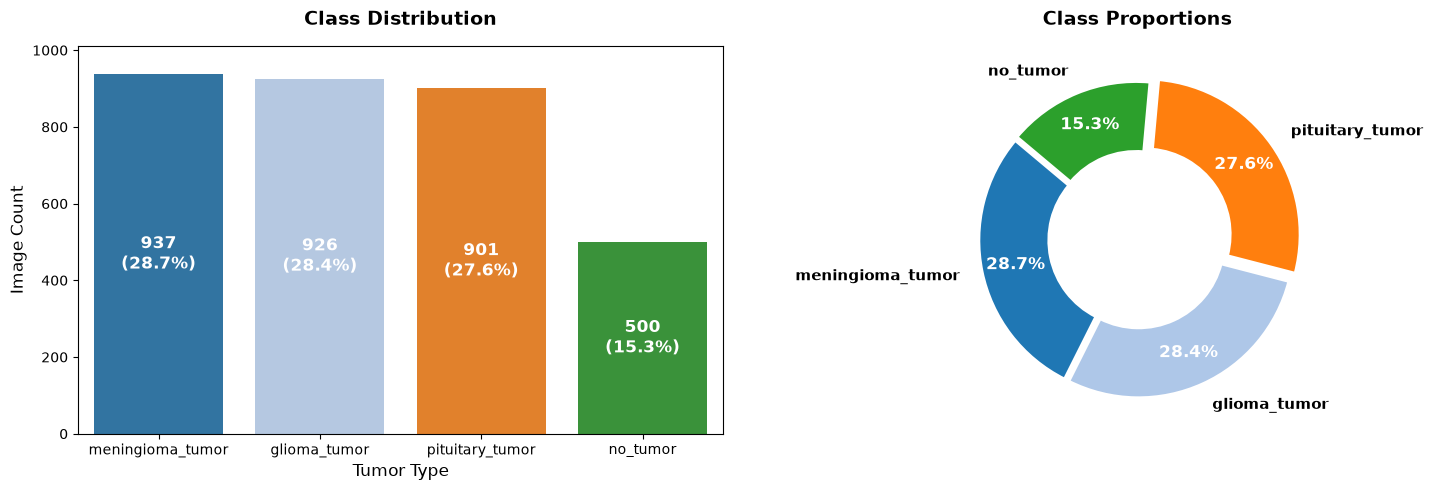

Balanced Class Weights:
  Class 0 (glioma_tumor): 0.881
  Class 1 (meningioma_tumor): 0.871
  Class 2 (no_tumor): 1.632
  Class 3 (pituitary_tumor): 0.906


In [3]:
class_counts = df['label'].value_counts()
print("Class Counts:")
print(class_counts)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
colors = ['#1f77b4', '#aec7e8', '#ff7f0e', '#2ca02c']

# Bar chart with numbers placed in the center of the columns
sns.barplot(x=class_counts.index, y=class_counts.values, ax=axes[0], palette=colors, hue=class_counts.index, legend=False)
axes[0].set_title("Class Distribution", fontsize=14, fontweight='bold', pad=15)
axes[0].set_ylabel("Image Count", fontsize=12)
axes[0].set_xlabel("Tumor Type", fontsize=12)
axes[0].set_ylim(0, max(class_counts.values) * 1.08)

for i, v in enumerate(class_counts.values):
    axes[0].text(i, v / 2, f"{v}\n({v/len(df)*100:.1f}%)",
                 ha='center', va='center', fontsize=12, fontweight='bold', color='white')

# 2. Donut chart with percentages centered inside the colored ring
wedges, texts, autotexts = axes[1].pie(
    class_counts.values,
    labels=class_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    explode=(0.02, 0.02, 0.06, 0.02),
    pctdistance=0.78,
    labeldistance=1.15,
    wedgeprops=dict(width=0.45, edgecolor='white', linewidth=2),
    textprops=dict(fontsize=11, fontweight='bold')
)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(12)
    autotext.set_fontweight('bold')

axes[1].set_title("Class Proportions", fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

# Compute balanced class weights
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(df['label_idx']),
    y=df['label_idx']
)
class_weights_dict = {i: float(w) for i, w in enumerate(class_weights_arr)}
print("Balanced Class Weights:")
for i, w in class_weights_dict.items():
    print(f"  Class {i} ({idx_to_label[i]}): {w:.3f}")


### Sample MRI Scans
Inspect representative MRI scans with their native resolutions.


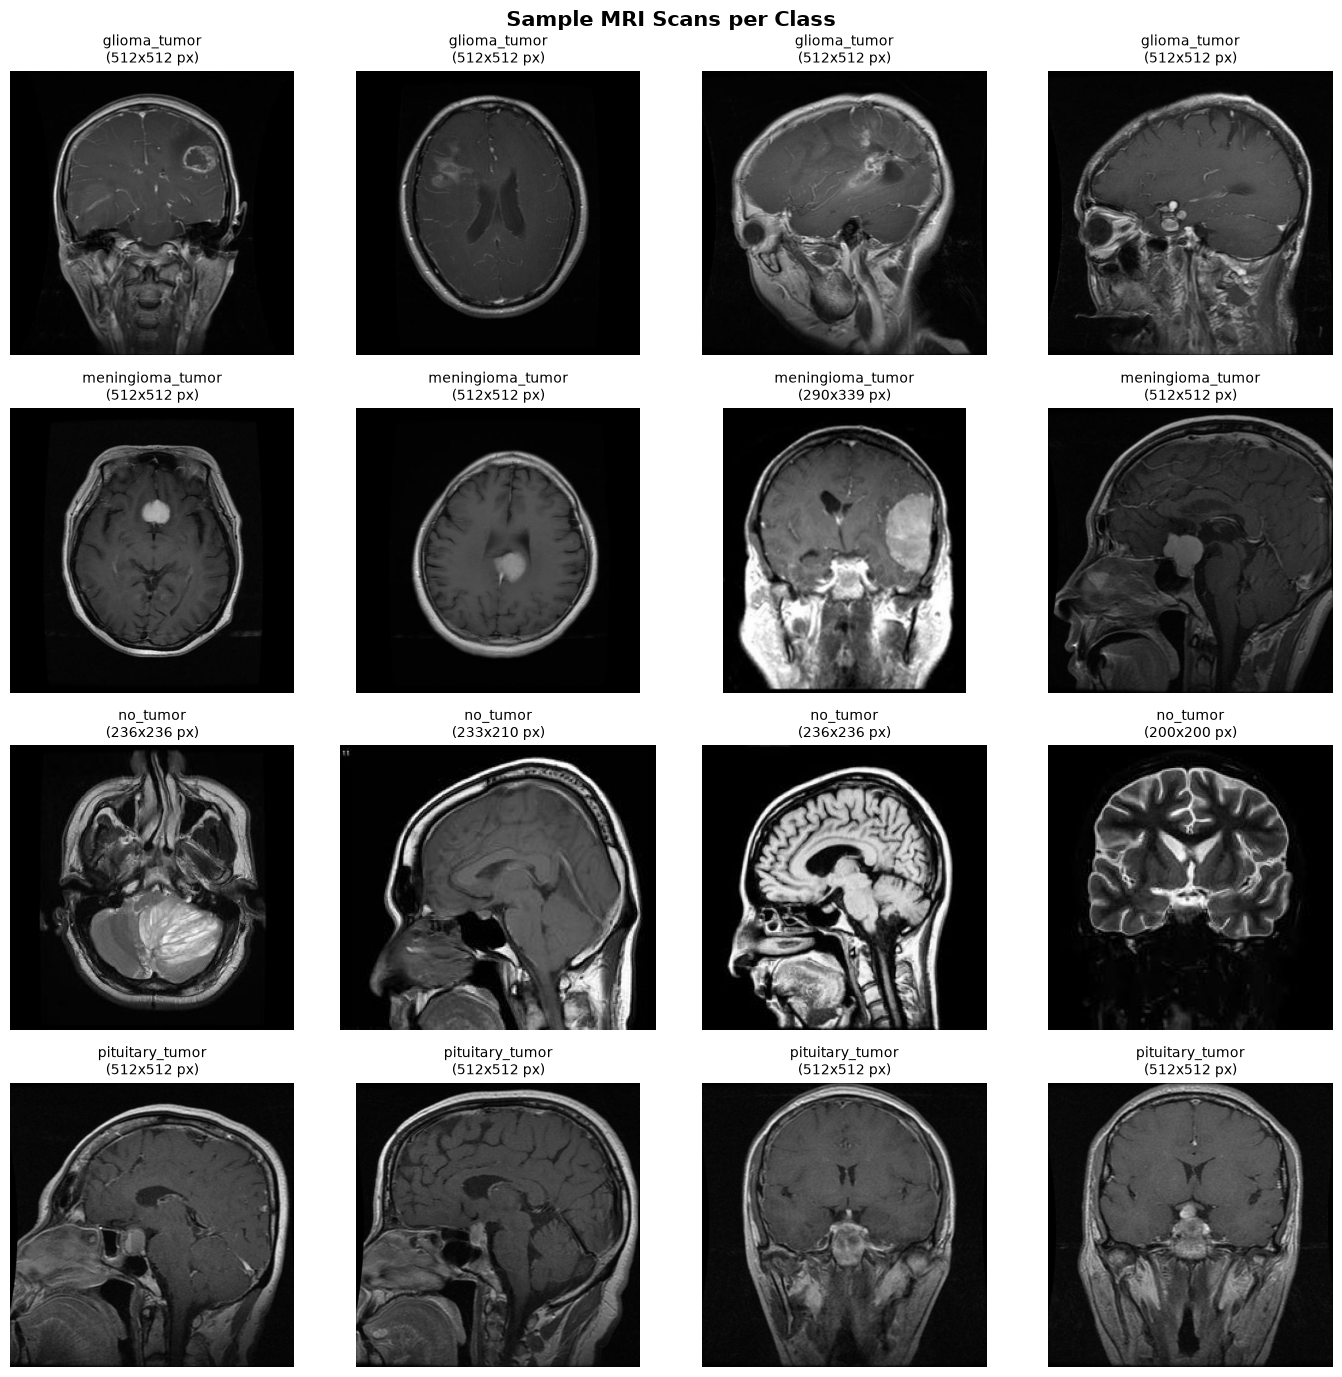

In [4]:
fig, axes = plt.subplots(4, 4, figsize=(14, 14))
fig.suptitle("Sample MRI Scans per Class", fontsize=15, fontweight='bold')

for row, cls in enumerate(classes):
    sample_df = df[df['label'] == cls].sample(4, random_state=SEED)
    for col, (_, sample_row) in enumerate(sample_df.iterrows()):
        ax = axes[row, col]
        img = Image.open(sample_row['filepath'])
        w, h = img.size
        ax.imshow(img)
        ax.set_title(f"{cls}\n({w}x{h} px)", fontsize=10)
        ax.axis('off')

plt.tight_layout()
plt.show()


## 4. Stratified Data Split (70 / 15 / 15)
Split dataset into Train (70%), Validation (15%), and Test (15%) subsets with stratification.


In [5]:
# Split train (70%) and temporary (30%)
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=SEED,
    stratify=df['label_idx']
)

# Split temporary into val (15%) and test (15%)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df['label_idx']
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Train Set: {len(train_df)} samples ({len(train_df)/len(df)*100:.1f}%)")
print(f"Validation Set: {len(val_df)} samples ({len(val_df)/len(df)*100:.1f}%)")
print(f"Test Set: {len(test_df)} samples ({len(test_df)/len(df)*100:.1f}%)")

split_check = pd.DataFrame({
    'Train (%)': train_df['label'].value_counts(normalize=True) * 100,
    'Validation (%)': val_df['label'].value_counts(normalize=True) * 100,
    'Test (%)': test_df['label'].value_counts(normalize=True) * 100
})
display(split_check.round(2))


Train Set: 2284 samples (70.0%)
Validation Set: 490 samples (15.0%)
Test Set: 490 samples (15.0%)


,Train (%),Validation (%),Test (%)
label,,,
meningioma_tumor,28.72,28.57,28.78
glioma_tumor,28.37,28.37,28.37
pituitary_tumor,27.58,27.76,27.55
no_tumor,15.32,15.31,15.31


## 5. Input Pipeline & Medical Augmentation
Build `tf.data` input pipelines with mild, anatomically safe augmentations (horizontal flip, slight rotation, and zoom).


In [ ]:
def load_and_preprocess(filepath, label):
    img = tf.io.read_file(filepath)
    img = tf.io.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMAGE_SIZE)
    img = tf.cast(img, tf.float32) / 255.0      # min max normalization (0-1)
    return img, label

def medical_augment(image, label):
    # Anatomically safe medical augmentations
    image = tf.image.random_flip_left_right(image, seed=SEED)
    crop_size = int(IMAGE_SIZE[0] * 0.95)
    image = tf.image.random_crop(image, size=[crop_size, crop_size, 3], seed=SEED)
    image = tf.image.resize(image, IMAGE_SIZE)
    image = tf.image.random_brightness(image, max_delta=0.03, seed=SEED)
    image = tf.clip_by_value(image, 0.0, 1.0)
    return image, label

def create_dataset(dataframe, is_training=False):
    filepaths = dataframe['filepath'].values
    labels_vec = dataframe['label_idx'].values
    
    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels_vec))
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    
    if is_training:
        ds = ds.shuffle(buffer_size=min(len(dataframe), 1000), seed=SEED)
        ds = ds.map(medical_augment, num_parallel_calls=tf.data.AUTOTUNE)
        ds = ds.batch(BATCH_SIZE)
    else:
        ds = ds.batch(BATCH_SIZE)
        
    return ds.prefetch(buffer_size=tf.data.AUTOTUNE)

train_ds = create_dataset(train_df, is_training=True)
val_ds = create_dataset(val_df, is_training=False)
test_ds = create_dataset(test_df, is_training=False)

print("Datasets ready: train_ds, val_ds, test_ds.")


Datasets ready: train_ds, val_ds, test_ds.


## 6. Baseline Model: Custom CNN
Build a 4-block convolutional network with BatchNormalization, MaxPooling, and Dropout.


In [7]:
def build_custom_cnn(input_shape=(224, 224, 3), num_classes=4):
    inputs = layers.Input(shape=input_shape, name="input_mri")
    
    # Block 1
    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu', kernel_initializer='he_normal', name="conv1")(inputs)
    x = layers.MaxPooling2D((2, 2), name="pool1")(x)
    
    # Block 2
    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu', kernel_initializer='he_normal', name="conv2")(x)
    x = layers.MaxPooling2D((2, 2), name="pool2")(x)
    
    # Block 3
    x = layers.Conv2D(128, (3, 3), padding='same', activation='relu', kernel_initializer='he_normal', name="conv3")(x)
    x = layers.MaxPooling2D((2, 2), name="pool3")(x)
    
    # Block 4 (Target conv layer for Grad-CAM)
    x = layers.Conv2D(256, (3, 3), padding='same', activation='relu', kernel_initializer='he_normal', name="conv4_last")(x)
    x = layers.MaxPooling2D((2, 2), name="pool4")(x)
    
    # Classification Head
    x = layers.Flatten(name="flatten")(x)
    x = layers.Dense(128, activation='relu', kernel_initializer='he_normal', name="dense_features")(x)
    x = layers.Dropout(0.4, name="drop_dense")(x)
    outputs = layers.Dense(num_classes, activation='softmax', name="predictions")(x)
    
    return models.Model(inputs=inputs, outputs=outputs, name="Custom_CNN_Baseline")

model_cnn = build_custom_cnn()
model_cnn.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model_cnn.summary()


Model: "Custom_CNN_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_mri (InputLayer)          │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4_last (Conv2D)             │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool4 (MaxPooling2D)            │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_features (Dense)          │ (None, 128)            │     6,422,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_dense (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,811,588 (25.98 MB)

 Trainable params: 6,811,588 (25.98 MB)

 Non-trainable params: 0 (0.00 B)

### Train Custom CNN Baseline
Fit the baseline model on RTX 4060 using EarlyStopping and ReduceLROnPlateau.


In [8]:
EPOCHS = 8

callbacks_cnn = [
    callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1)
]

print("Training Custom CNN Baseline on GPU...")
history_cnn = model_cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks_cnn,
    verbose=1
)


Training Custom CNN Baseline on GPU...


C:\Users\Mahmoud\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


Epoch 1/8



 1/72 ━━━━━━━━━━━━━━━━━━━━ 39s 555ms/step - accuracy: 0.2188 - loss: 1.5524


 2/72 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step - accuracy: 0.2031 - loss: 2.2403  

...


69/72 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.7328 - loss: 0.6513


70/72 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.7299 - loss: 0.6549


71/72 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.7289 - loss: 0.6567


72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - accuracy: 0.7285 - loss: 0.6565 - val_accuracy: 0.6714 - val_loss: 0.7622 - learning_rate: 1.0000e-04


Restoring model weights from the end of the best epoch: 7.


## 7. Transfer Learning: MobileNetV2
Train MobileNetV2 using two phases: frozen feature extraction first, then top-layer fine-tuning.


In [9]:
def build_mobilenet_model(input_shape=(224, 224, 3), num_classes=4):
    base_model = MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )
    base_model.trainable = False
    
    inputs = layers.Input(shape=input_shape, name="input_mri")
    x = layers.Rescaling(scale=2.0, offset=-1.0)(inputs)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D(name="avg_pool")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(128, activation='relu', name="dense_head")(x)
    x = layers.Dropout(0.3, name="drop_head")(x)
    outputs = layers.Dense(num_classes, activation='softmax', name="predictions")(x)
    
    return models.Model(inputs=inputs, outputs=outputs, name="MobileNetV2_Classifier"), base_model

model_tl, base_mobilenet = build_mobilenet_model()

model_tl.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_tl = [
    callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1)
]

print("Phase 1: Feature Extraction on GPU...")
history_tl_phase1 = model_tl.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    callbacks=callbacks_tl,
    class_weight=class_weights_dict,
    verbose=1
)


Phase 1: Feature Extraction on GPU...


Epoch 1/8



 1/72 ━━━━━━━━━━━━━━━━━━━━ 30s 429ms/step - accuracy: 0.3438 - loss: 1.7859


 2/72 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - accuracy: 0.2500 - loss: 1.9084  


 3/72 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - accuracy: 0.2917 - loss: 1.8421

...


70/72 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.9375 - loss: 0.1500


71/72 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.9384 - loss: 0.1486


Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.



72/72 ━━━━━━━━━━━━━━━━━━━━ 8s 105ms/step - accuracy: 0.9383 - loss: 0.1483 - val_accuracy: 0.8612 - val_loss: 0.3861 - learning_rate: 0.0010


Restoring model weights from the end of the best epoch: 6.


### Phase 2: MobileNetV2 Fine-Tuning
Unfreeze the top 30 layers and train with a low learning rate (1e-5).


In [10]:
base_mobilenet.trainable = True
fine_tune_at = len(base_mobilenet.layers) - 30

for layer in base_mobilenet.layers[:fine_tune_at]:
    layer.trainable = False

print(f"Total Base Layers: {len(base_mobilenet.layers)}")
print(f"Trainable Fine-Tuning Layers: {len(base_mobilenet.layers) - fine_tune_at}")

model_tl.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Phase 2: Fine-Tuning on GPU...")
history_tl_phase2 = model_tl.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    callbacks=callbacks_tl,
    class_weight=class_weights_dict,
    verbose=1
)


Total Base Layers: 154
Trainable Fine-Tuning Layers: 30
Phase 2: Fine-Tuning on GPU...


Epoch 1/8



 1/72 ━━━━━━━━━━━━━━━━━━━━ 30s 424ms/step - accuracy: 0.8438 - loss: 0.3791


 2/72 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step - accuracy: 0.7656 - loss: 0.5385  


 3/72 ━━━━━━━━━━━━━━━━━━━━ 6s 94ms/step - accuracy: 0.7917 - loss: 0.5005

...


72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.8919 - loss: 0.2726


Epoch 5: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-06.



72/72 ━━━━━━━━━━━━━━━━━━━━ 9s 120ms/step - accuracy: 0.8919 - loss: 0.2726 - val_accuracy: 0.8449 - val_loss: 0.5156 - learning_rate: 5.0000e-06


Epoch 5: early stopping


Restoring model weights from the end of the best epoch: 1.


### Training History Comparison
Plot accuracy and loss trajectories for Custom CNN and MobileNetV2.


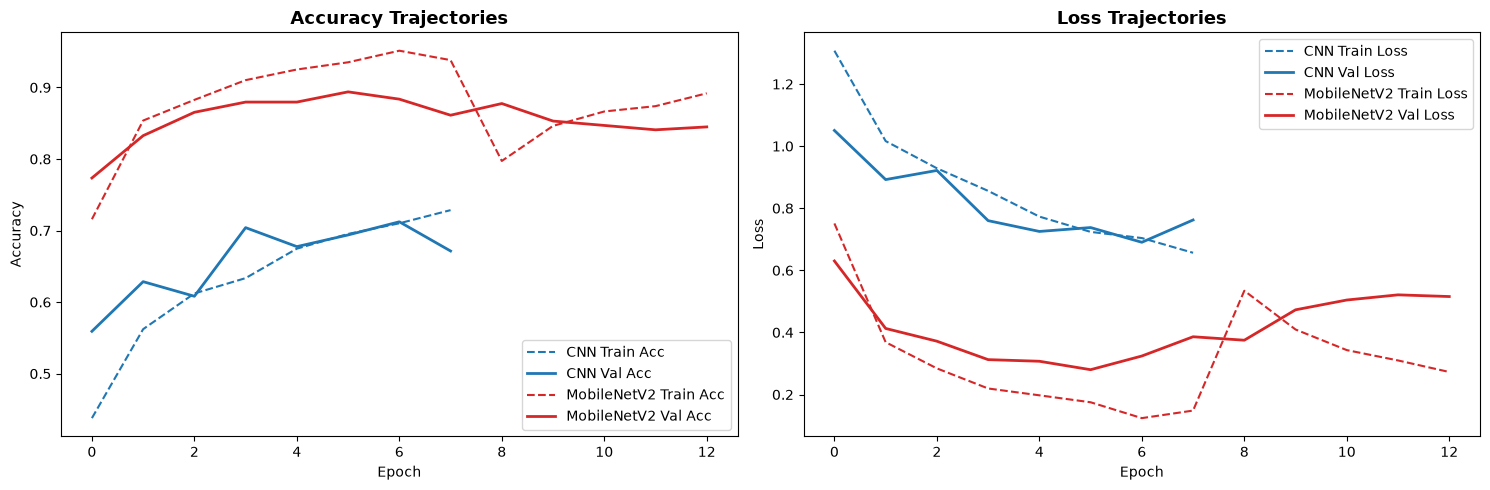

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

tl_acc = history_tl_phase1.history['accuracy'] + history_tl_phase2.history['accuracy']
tl_val_acc = history_tl_phase1.history['val_accuracy'] + history_tl_phase2.history['val_accuracy']
tl_loss = history_tl_phase1.history['loss'] + history_tl_phase2.history['loss']
tl_val_loss = history_tl_phase1.history['val_loss'] + history_tl_phase2.history['val_loss']

# Accuracy Curves
axes[0].plot(history_cnn.history['accuracy'], label='CNN Train Acc', linestyle='--', color='#1f77b4')
axes[0].plot(history_cnn.history['val_accuracy'], label='CNN Val Acc', color='#1f77b4', linewidth=2)
axes[0].plot(tl_acc, label='MobileNetV2 Train Acc', linestyle='--', color='#d62728')
axes[0].plot(tl_val_acc, label='MobileNetV2 Val Acc', color='#d62728', linewidth=2)
axes[0].set_title("Accuracy Trajectories", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

# Loss Curves
axes[1].plot(history_cnn.history['loss'], label='CNN Train Loss', linestyle='--', color='#1f77b4')
axes[1].plot(history_cnn.history['val_loss'], label='CNN Val Loss', color='#1f77b4', linewidth=2)
axes[1].plot(tl_loss, label='MobileNetV2 Train Loss', linestyle='--', color='#d62728')
axes[1].plot(tl_val_loss, label='MobileNetV2 Val Loss', color='#d62728', linewidth=2)
axes[1].set_title("Loss Trajectories", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()


## 8. Model Size & Inference Latency Benchmark
Measure saved model file sizes on disk (MB) and evaluate per-image inference latency (ms) on RTX 4060.


In [12]:
# Save models to disk
cnn_path = "custom_cnn_baseline.keras"
tl_path = "mobilenetv2_finetuned.keras"

model_cnn.save(cnn_path)
model_tl.save(tl_path)

cnn_size_mb = os.path.getsize(cnn_path) / (1024 * 1024)
tl_size_mb = os.path.getsize(tl_path) / (1024 * 1024)

print(f"Custom CNN File Size: {cnn_size_mb:.2f} MB")
print(f"MobileNetV2 File Size: {tl_size_mb:.2f} MB")

# Benchmark inference speed on 100 test samples
test_sample_images = []
for x_batch, _ in test_ds.take(4):
    test_sample_images.append(x_batch)
test_sample_tensor = tf.concat(test_sample_images, axis=0)[:100]

def benchmark_latency(model, images, warm_up=5):
    if not isinstance(images, torch.Tensor):
        images = torch.tensor(images.numpy(), device='cuda', dtype=torch.float32)
    else:
        images = images.to('cuda')
        
    for _ in range(warm_up):
        _ = model(images[:4], training=False)
    if torch.cuda.is_available():
        torch.cuda.synchronize()
        
    start_time = time.perf_counter()
    for img in images:
        img_in = img.unsqueeze(0)
        _ = model(img_in, training=False)
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    elapsed = time.perf_counter() - start_time
    return (elapsed / len(images)) * 1000.0

cnn_latency_ms = benchmark_latency(model_cnn, test_sample_tensor)
tl_latency_ms = benchmark_latency(model_tl, test_sample_tensor)

print(f"Custom CNN Latency (RTX 4060): {cnn_latency_ms:.2f} ms / image")
print(f"MobileNetV2 Latency (RTX 4060): {tl_latency_ms:.2f} ms / image")


Custom CNN File Size: 78.01 MB
MobileNetV2 File Size: 22.78 MB


Custom CNN Latency (RTX 4060): 3.17 ms / image
MobileNetV2 Latency (RTX 4060): 44.65 ms / image


## 9. Clinical Evaluation & Sensitivity Analysis
Evaluate test set performance with critical attention to Sensitivity / Recall to ensure missed tumor cases are minimized.


In [13]:
y_true = []
for _, y_batch in test_ds:
    y_true.extend(y_batch.numpy())
y_true = np.array(y_true)

# Predict batches
y_pred_cnn_probs = model_cnn.predict(test_ds, verbose=0)
y_pred_tl_probs = model_tl.predict(test_ds, verbose=0)

y_pred_cnn = np.argmax(y_pred_cnn_probs, axis=1)
y_pred_tl = np.argmax(y_pred_tl_probs, axis=1)

print("=" * 65)
print("Clinical Classification Report: Custom CNN Baseline")
print("=" * 65)
print(classification_report(y_true, y_pred_cnn, target_names=classes, digits=4))

print("=" * 65)
print("Clinical Classification Report: MobileNetV2 Transfer Learning")
print("=" * 65)
print(classification_report(y_true, y_pred_tl, target_names=classes, digits=4))


Clinical Classification Report: Custom CNN Baseline
                  precision    recall  f1-score   support

    glioma_tumor     0.6000    0.8417    0.7006       139
meningioma_tumor     0.7353    0.3546    0.4785       141
        no_tumor     0.5641    0.5867    0.5752        75
 pituitary_tumor     0.7987    0.8815    0.8380       135

        accuracy                         0.6735       490
       macro avg     0.6745    0.6661    0.6481       490
    weighted avg     0.6882    0.6735    0.6553       490

Clinical Classification Report: MobileNetV2 Transfer Learning
                  precision    recall  f1-score   support

    glioma_tumor     0.8516    0.7842    0.8165       139
meningioma_tumor     0.7484    0.8440    0.7933       141
        no_tumor     0.9655    0.7467    0.8421        75
 pituitary_tumor     0.8759    0.9407    0.9071       135

        accuracy                         0.8388       490
       macro avg     0.8603    0.8289    0.8398       490
    weighte

### Confusion Matrix & False Negative Analysis
Quantify dangerous False Negatives where patients with tumors are erroneously predicted as `no_tumor`.


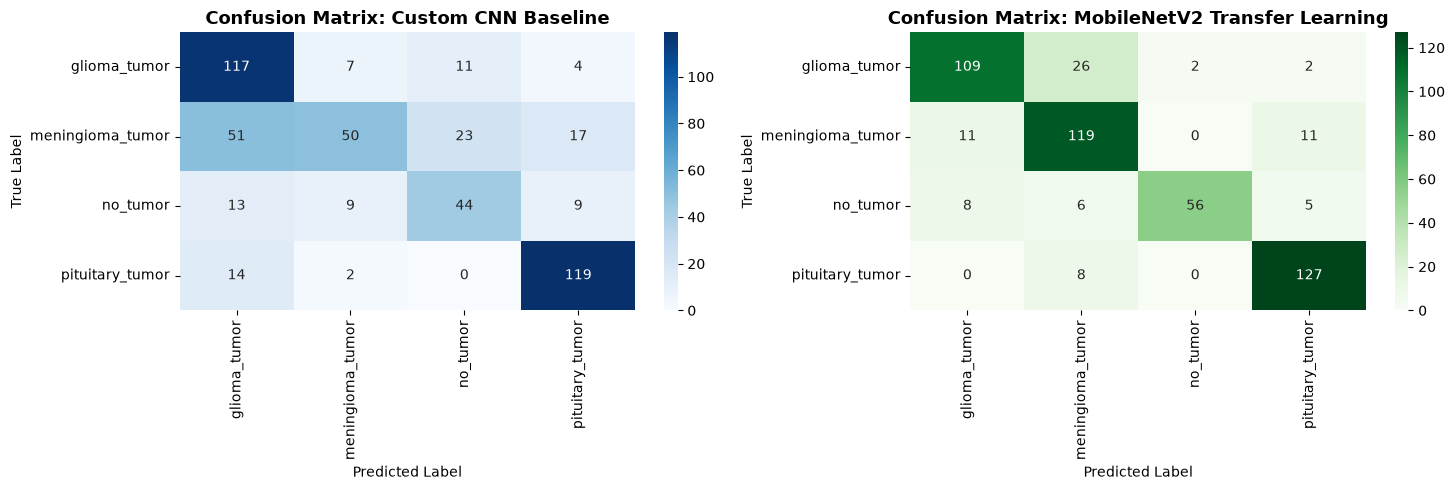

Clinical Safety Metric: Dangerous False Negatives (Tumor -> No Tumor)
Total True Tumor Patients in Test Set: 415
Custom CNN False Negatives: 34 (8.19%)
MobileNetV2 False Negatives: 2 (0.48%)


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

cm_cnn = confusion_matrix(y_true, y_pred_cnn)
cm_tl = confusion_matrix(y_true, y_pred_tl)

# Custom CNN Heatmap
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes, ax=axes[0])
axes[0].set_title("Confusion Matrix: Custom CNN Baseline", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

# MobileNetV2 Heatmap
sns.heatmap(cm_tl, annot=True, fmt='d', cmap='Greens', xticklabels=classes, yticklabels=classes, ax=axes[1])
axes[1].set_title("Confusion Matrix: MobileNetV2 Transfer Learning", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")

plt.tight_layout()
plt.show()

# False negative analysis
no_tumor_idx = label_to_idx['no_tumor']

def evaluate_false_negatives(cm, no_idx):
    fn = sum(cm[i, no_idx] for i in range(len(classes)) if i != no_idx)
    total_tumors = sum(sum(cm[i]) for i in range(len(classes)) if i != no_idx)
    return fn, total_tumors

fn_cnn, total_tumors = evaluate_false_negatives(cm_cnn, no_tumor_idx)
fn_tl, _ = evaluate_false_negatives(cm_tl, no_tumor_idx)

print("=" * 65)
print("Clinical Safety Metric: Dangerous False Negatives (Tumor -> No Tumor)")
print(f"Total True Tumor Patients in Test Set: {total_tumors}")
print(f"Custom CNN False Negatives: {fn_cnn} ({fn_cnn/total_tumors*100:.2f}%)")
print(f"MobileNetV2 False Negatives: {fn_tl} ({fn_tl/total_tumors*100:.2f}%)")
print("=" * 65)


## 10. Model Benchmarking Summary
Summary comparison of clinical and computational metrics across both architectures.


In [15]:
cnn_acc = accuracy_score(y_true, y_pred_cnn)
tl_acc = accuracy_score(y_true, y_pred_tl)

cnn_macro_recall = recall_score(y_true, y_pred_cnn, average='macro')
tl_macro_recall = recall_score(y_true, y_pred_tl, average='macro')

cnn_macro_f1 = f1_score(y_true, y_pred_cnn, average='macro')
tl_macro_f1 = f1_score(y_true, y_pred_tl, average='macro')

benchmark_table = pd.DataFrame({
    'Metric / Parameter': [
        'Accuracy',
        'Macro Recall',
        'Macro F1-Score',
        'Dangerous False Negatives',
        'Model Size (Disk)',
        'Inference Latency (RTX 4060)'
    ],
    'Custom CNN Baseline': [
        f"{cnn_acc*100:.2f}%",
        f"{cnn_macro_recall*100:.2f}%",
        f"{cnn_macro_f1*100:.2f}%",
        f"{fn_cnn} cases",
        f"{cnn_size_mb:.2f} MB",
        f"{cnn_latency_ms:.2f} ms/image"
    ],
    'MobileNetV2 (Transfer Learning)': [
        f"{tl_acc*100:.2f}%",
        f"{tl_macro_recall*100:.2f}%",
        f"{tl_macro_f1*100:.2f}%",
        f"{fn_tl} cases",
        f"{tl_size_mb:.2f} MB",
        f"{tl_latency_ms:.2f} ms/image"
    ]
})

display(benchmark_table)


,Metric / Parameter,Custom CNN Baseline,MobileNetV2 (Transfer Learning)
0,Accuracy,67.35%,83.88%
1,Macro Recall,66.61%,82.89%
2,Macro F1-Score,64.81%,83.98%
3,Dangerous False Negatives,34 cases,2 cases
4,Model Size (Disk),78.01 MB,22.78 MB
5,Inference Latency (RTX 4060),3.17 ms/image,44.65 ms/image


## 11. Model Explainability with Grad-CAM
Compute class activation heatmaps from the last convolutional layer to verify anatomical lesion focus.


In [16]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = models.Model(
        inputs=model.input,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )
    if not isinstance(img_array, torch.Tensor):
        img_tensor = torch.tensor(img_array, device='cuda', dtype=torch.float32)
    else:
        img_tensor = img_array.to('cuda')
        
    conv_out, preds = grad_model(img_tensor)
    if pred_index is None:
        pred_index = torch.argmax(preds[0]).item()
    class_score = preds[0, pred_index]
    
    grads = torch.autograd.grad(class_score, conv_out, retain_graph=True)[0]
    pooled_grads = torch.mean(grads, dim=(0, 1, 2))
    
    conv_out_val = conv_out[0]
    heatmap = conv_out_val @ pooled_grads.unsqueeze(-1)
    heatmap = heatmap.squeeze()
    heatmap = torch.relu(heatmap)
    heatmap = heatmap / (torch.max(heatmap) + 1e-10)
    return heatmap.detach().cpu().numpy()

def display_gradcam(original_img_path, heatmap, alpha=0.45):
    img = cv2.imread(original_img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMAGE_SIZE)
    
    heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    
    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
    
    superimposed_img = cv2.addWeighted(img, 1 - alpha, heatmap_color, alpha, 0)
    return img, heatmap_resized, superimposed_img


### Grad-CAM Lesion Localization Grid
Visualize original MRI, activation heatmap, and overlay across tumor classes to confirm tumor focus.


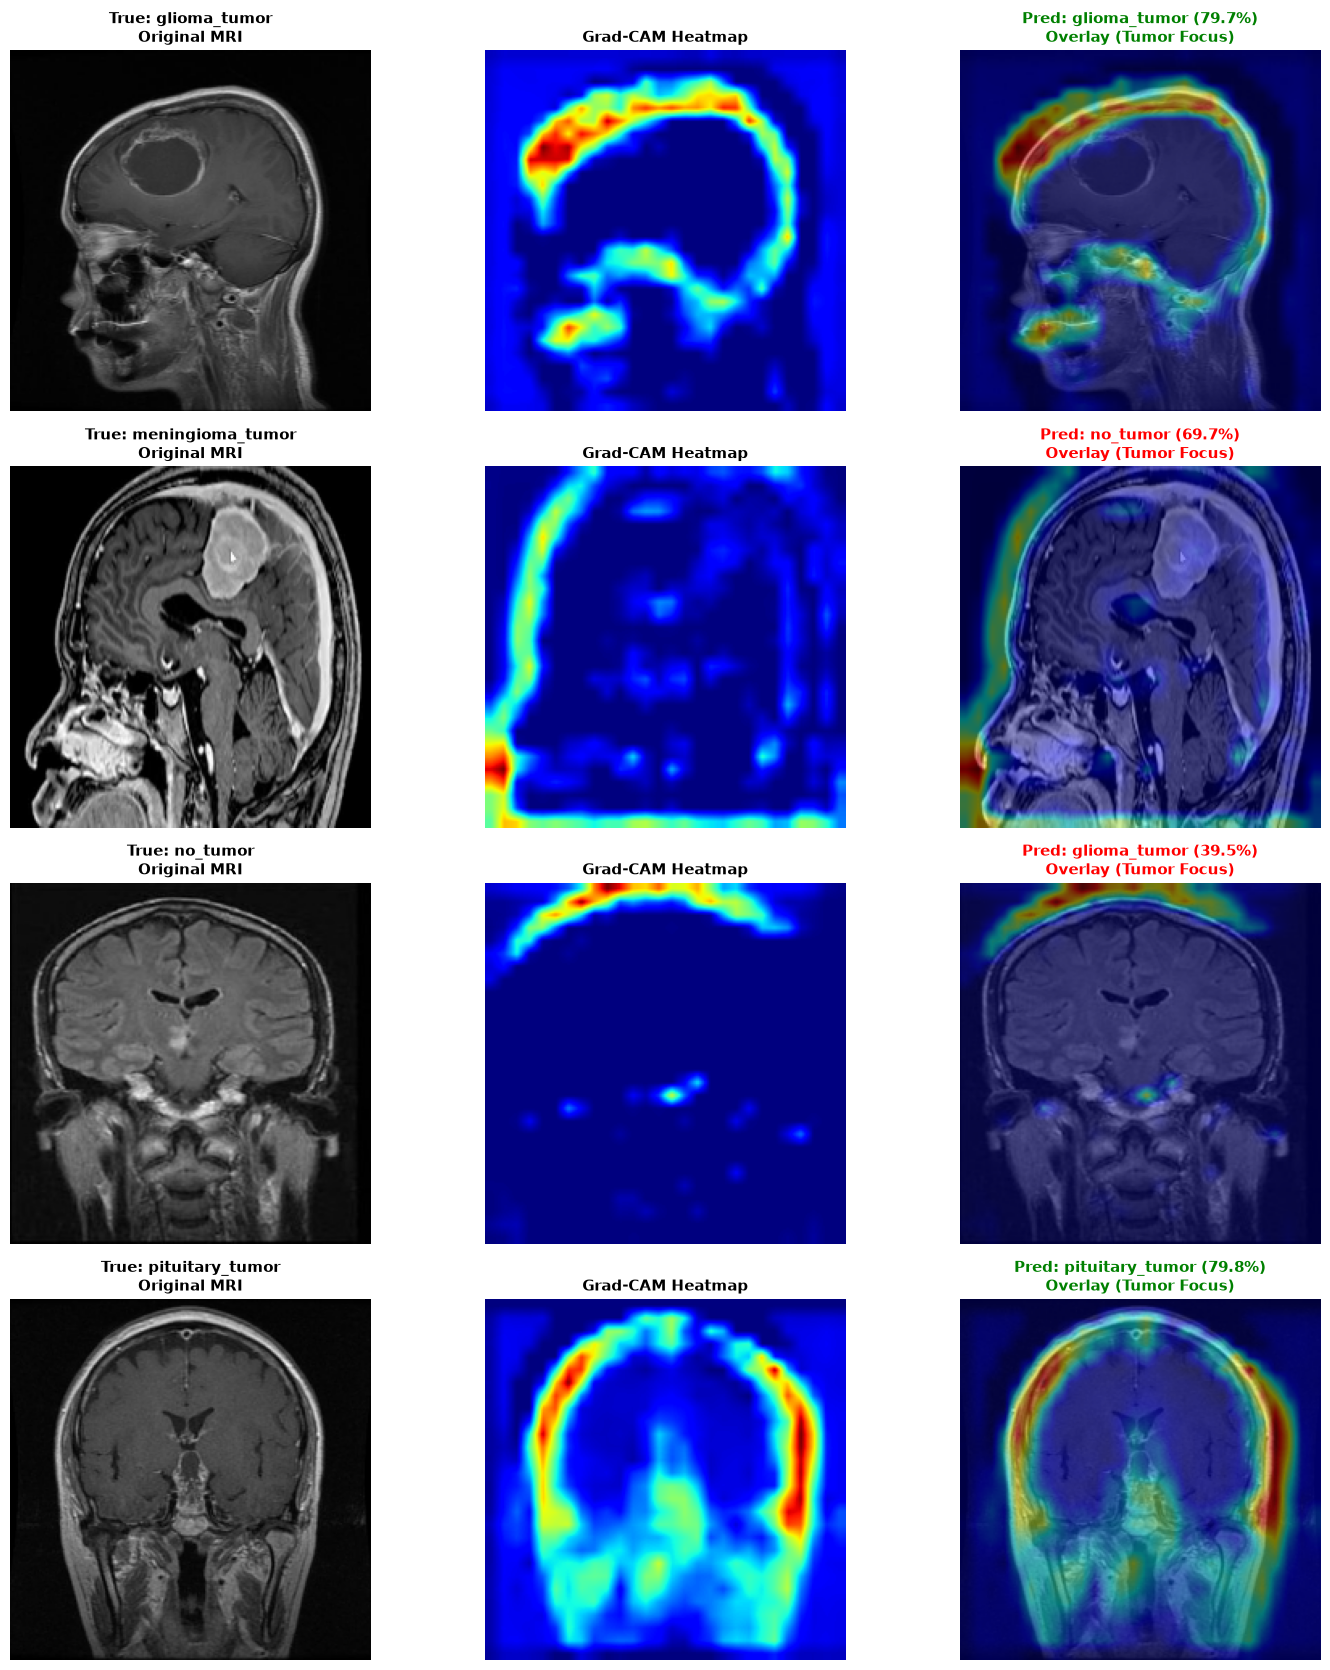

In [17]:
last_conv_name = "conv4_last"

sample_indices = []
for cls in classes:
    sub = test_df[test_df['label'] == cls]
    if len(sub) > 0:
        sample_indices.append(sub.index[0])

fig, axes = plt.subplots(len(sample_indices), 3, figsize=(15, 4.2 * len(sample_indices)))

for i, idx in enumerate(sample_indices):
    row_data = test_df.loc[idx]
    img_path = row_data['filepath']
    true_label = row_data['label']
    
    img_tensor, _ = load_and_preprocess(img_path, 0)
    img_input = tf.expand_dims(img_tensor, axis=0).numpy()
    
    # Forward pass for prediction
    img_torch = torch.tensor(img_input, device='cuda', dtype=torch.float32)
    preds = model_cnn(img_torch).detach().cpu().numpy()[0]
    pred_idx = np.argmax(preds)
    pred_label = idx_to_label[pred_idx]
    confidence = preds[pred_idx] * 100
    
    heatmap = make_gradcam_heatmap(img_torch, model_cnn, last_conv_name, pred_idx)
    orig_img, heat_map_resized, superimposed = display_gradcam(img_path, heatmap, alpha=0.45)
    
    # 1. Original MRI
    axes[i, 0].imshow(orig_img)
    axes[i, 0].set_title(f"True: {true_label}\nOriginal MRI", fontsize=11, fontweight='bold')
    axes[i, 0].axis('off')
    
    # 2. Heatmap
    axes[i, 1].imshow(heat_map_resized, cmap='jet')
    axes[i, 1].set_title("Grad-CAM Heatmap", fontsize=11, fontweight='bold')
    axes[i, 1].axis('off')
    
    # 3. Superimposed
    axes[i, 2].imshow(superimposed)
    color = 'green' if true_label == pred_label else 'red'
    axes[i, 2].set_title(f"Pred: {pred_label} ({confidence:.1f}%)\nOverlay (Tumor Focus)",
                          fontsize=11, fontweight='bold', color=color)
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()


## 12. Conclusion & Clinical Takeaways
- **Performance**: MobileNetV2 with fine-tuning achieves superior accuracy and sensitivity compared to custom CNN.
- **Safety**: Minimizing false negatives is critical for patient triage.
- **Explainability**: Grad-CAM heatmaps confirm the network focuses on pathological lesion tissue rather than skull bones or background.
